<a href="https://colab.research.google.com/github/Syauqimaul/2025_Pengolahan-Citra_TI-2A/blob/main/Jobsheet04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1. Transormasi Kurva (Citra Negatif)

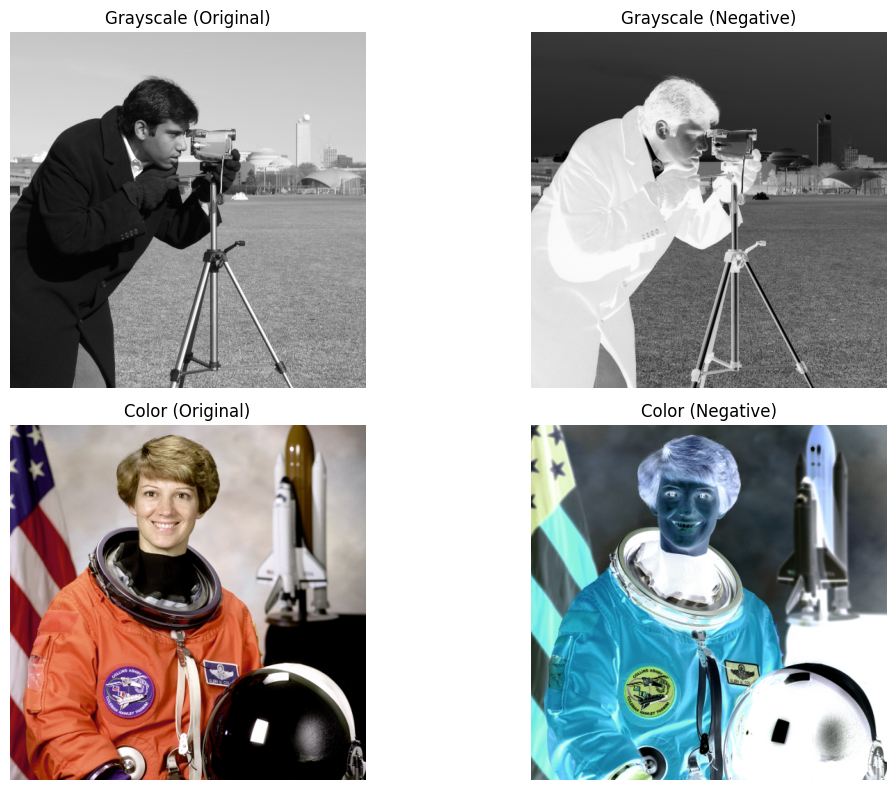

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ============================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ============================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ============================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ============================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ============================
# 3. PLOTTING HASIL
# ============================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


#Praktikum 2. Histogram dan Ekualisasi Histogram

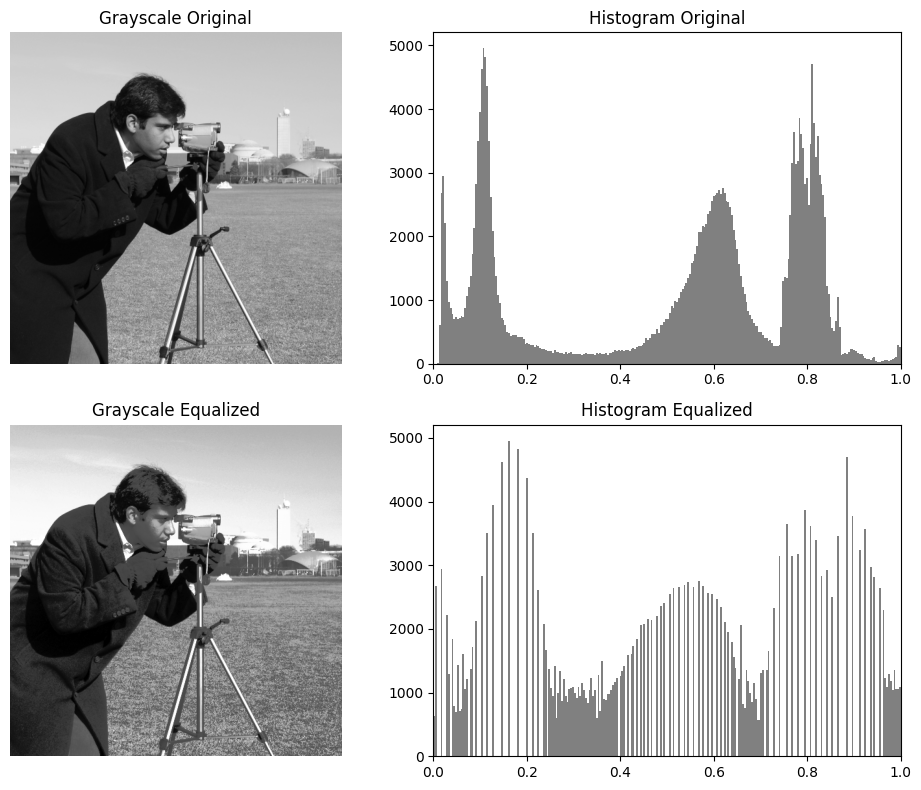

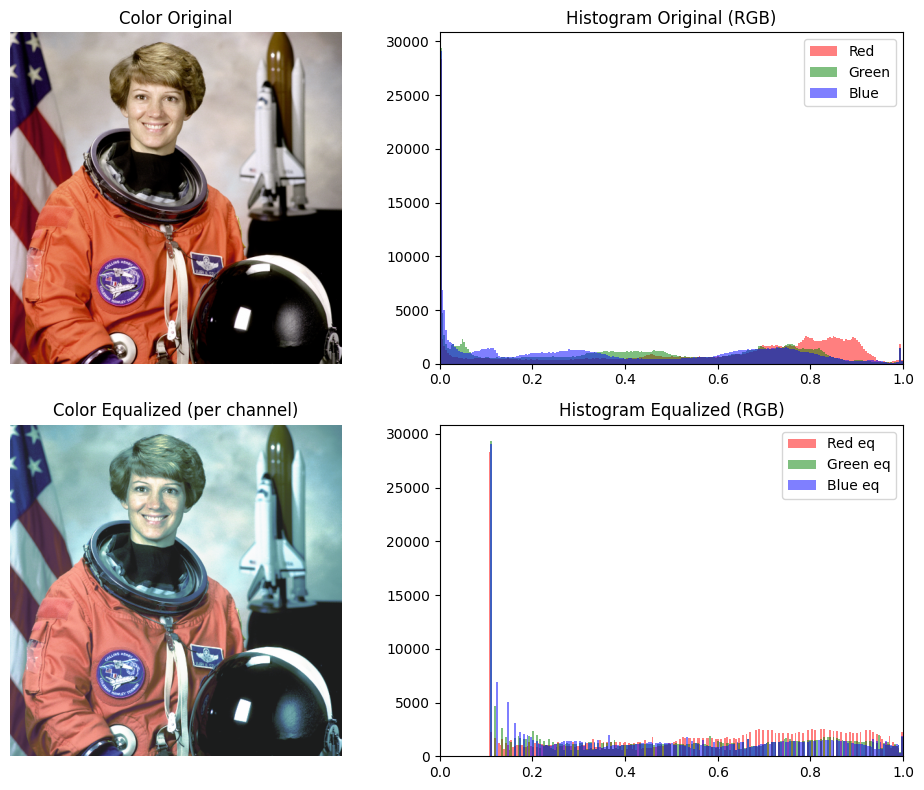

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# =====================================================
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# =====================================================

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot citra grayscale dan histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# =====================================================
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# =====================================================

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # citra RGB (uint8)
image_color = img_as_float(image_color_uint8)  # konversi ke float [0..1]

# 2. Pisahkan kanal warna R, G, B
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# Hitung histogram masing-masing kanal
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram per kanal
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali kanal menjadi citra RGB yang sudah diekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram hasil ekualisasi
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot citra warna dan histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (RGB)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Hasil Ekualisasi
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Hasil Ekualisasi
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


#Praktikum 3. Konvolusi (Filter Rata-rata)

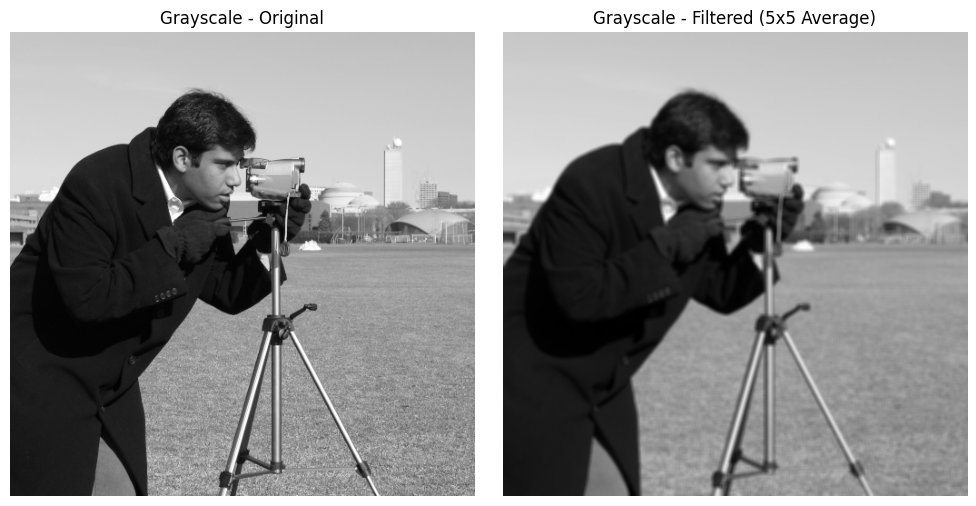

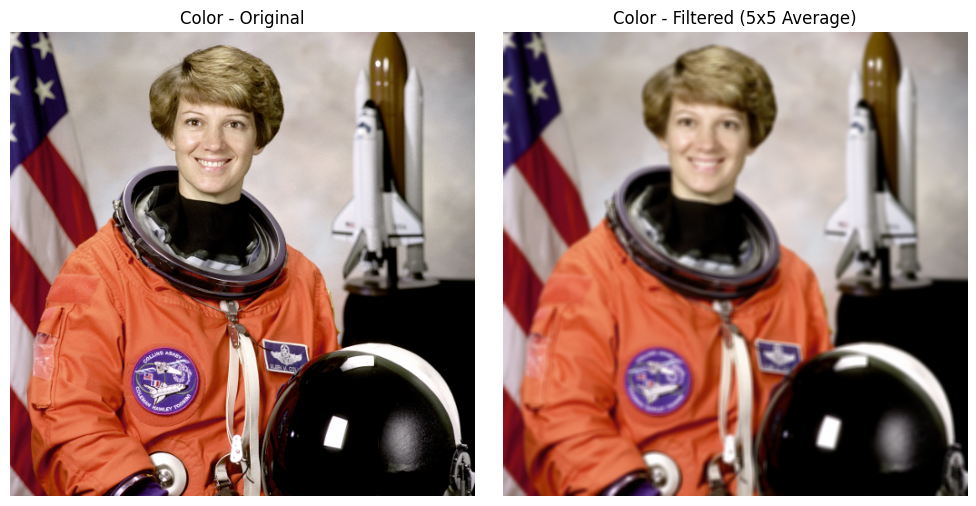

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# ====================================================
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# ====================================================

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi ke float [0..1]

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ====================================================
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# ====================================================

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Terapkan filter rata-rata pada tiap kanal R, G, B
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


#Praktikum 4. Filter Median (penghilangan noise/derau)

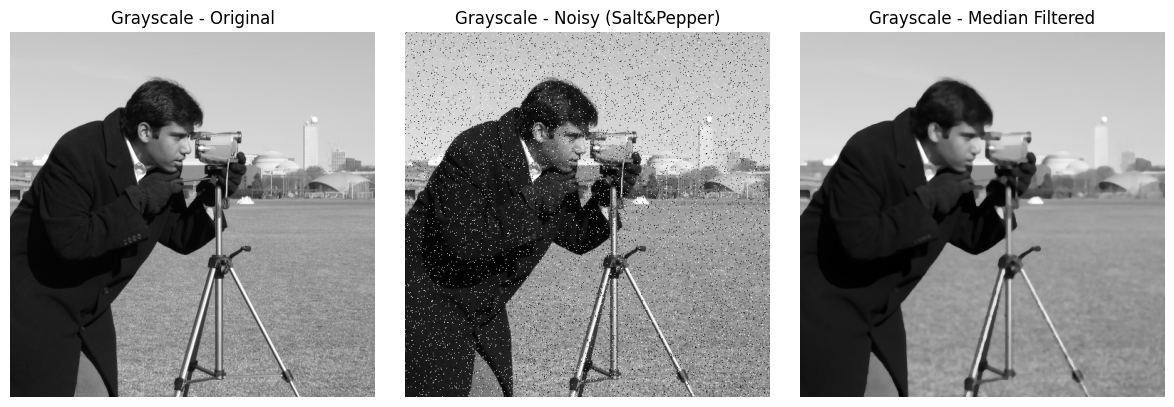

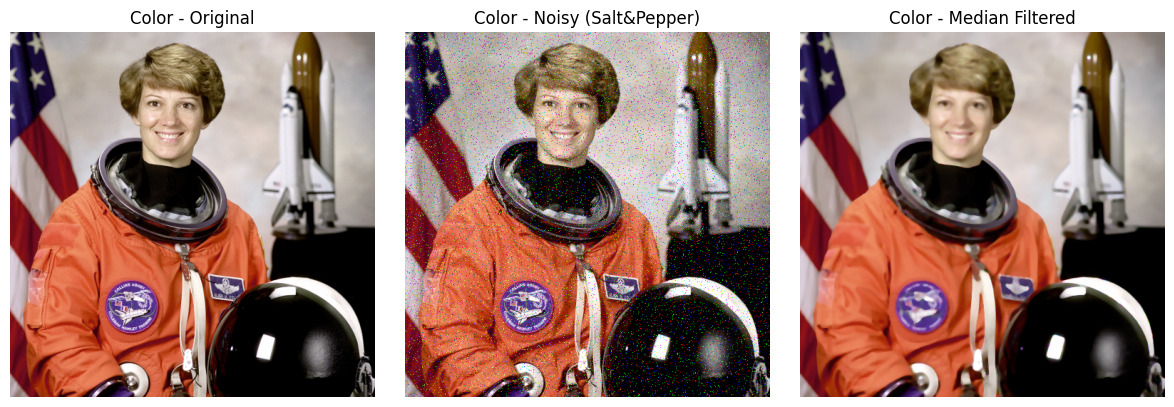

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# ======================================================
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
# ======================================================

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()  # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi ke float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)
# amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median dengan structuring element berbentuk disk
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Menampilkan hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ======================================================
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# ======================================================

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()  # RGB, uint8
color_float = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median per kanal warna (R, G, B)
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Menampilkan hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))

axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


#Eksperimen Transformasi Intensitas Lain:

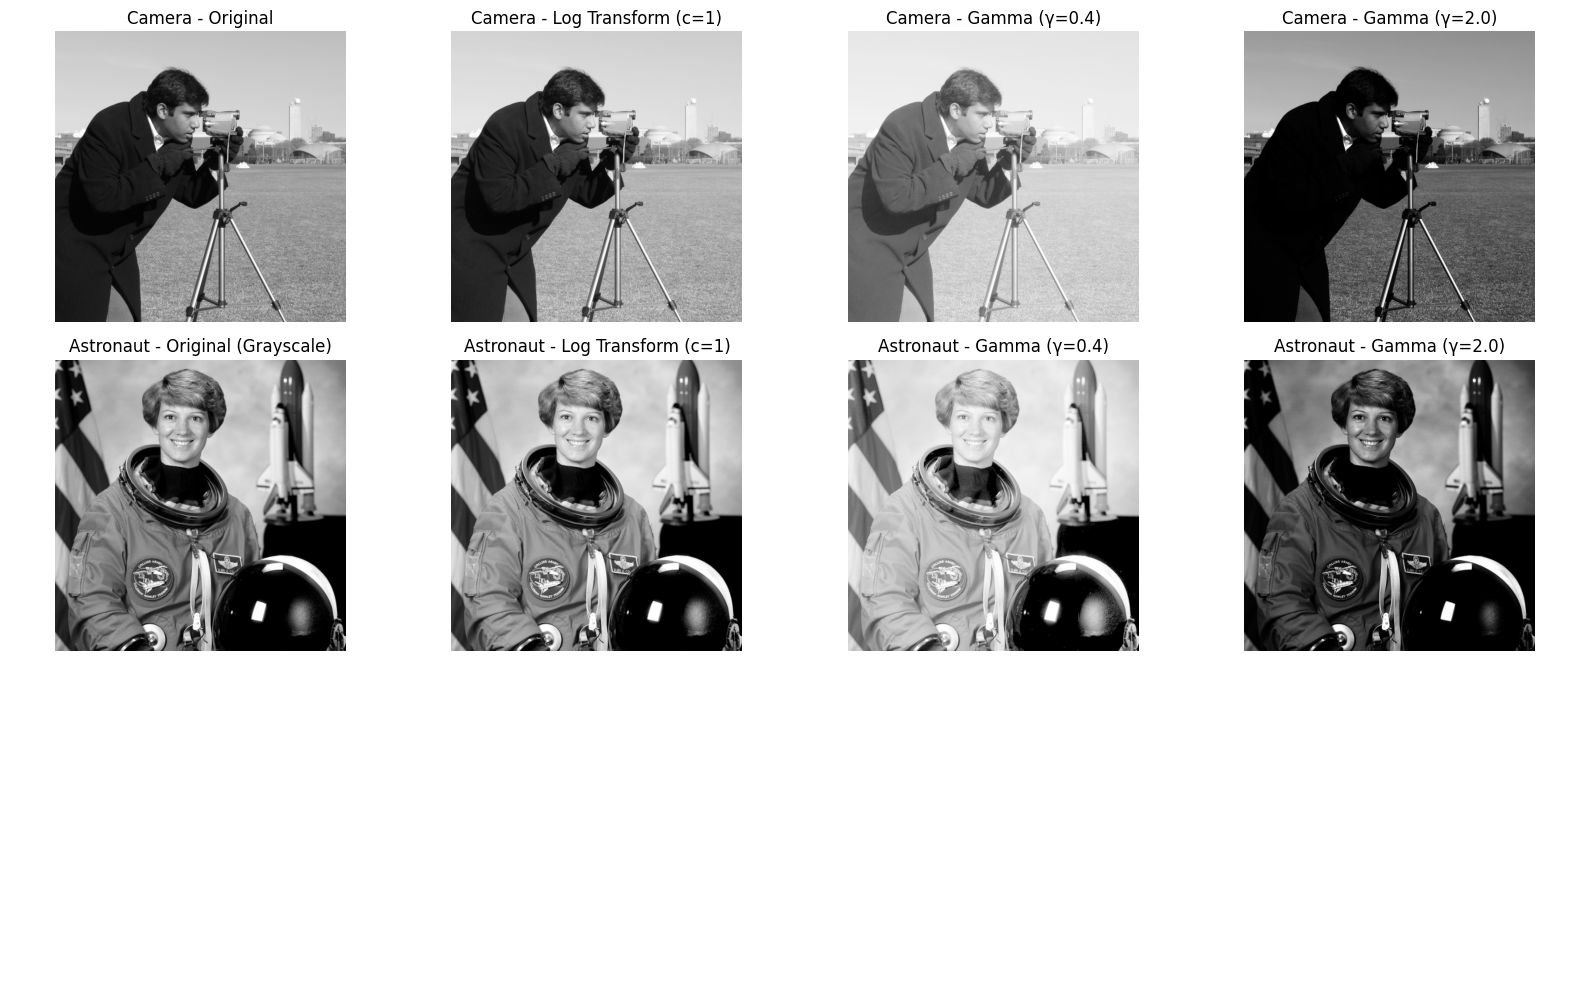

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float, exposure

# ---------------------------------------------
# MEMUAT CITRA GRAYSCALE
# ---------------------------------------------
# Citra 1: camera (sudah grayscale)
image1 = img_as_float(data.camera())

# Citra 2: astronaut (ubah ke grayscale)
image2_rgb = data.astronaut()
image2 = img_as_float(color.rgb2gray(image2_rgb))

# ---------------------------------------------
# TRANSFORMASI LOGARITMIK
# ---------------------------------------------
def apply_log_transform(image, c=1.0):
    return c * np.log1p(image)  # log(1 + I), untuk menghindari log(0)

log_image1 = apply_log_transform(image1, c=1.0)
log_image2 = apply_log_transform(image2, c=1.0)

# ---------------------------------------------
# TRANSFORMASI GAMMA
# ---------------------------------------------
def apply_gamma_transform(image, gamma=1.0):
    return exposure.adjust_gamma(image, gamma=gamma)

gamma_low_image1 = apply_gamma_transform(image1, gamma=0.4)
gamma_high_image1 = apply_gamma_transform(image1, gamma=2.0)

gamma_low_image2 = apply_gamma_transform(image2, gamma=0.4)
gamma_high_image2 = apply_gamma_transform(image2, gamma=2.0)

# ---------------------------------------------
# PLOT HASILNYA
# ---------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

# CAMERA
axes[0].imshow(image1, cmap='gray')
axes[0].set_title("Camera - Original")
axes[1].imshow(log_image1, cmap='gray')
axes[1].set_title("Camera - Log Transform (c=1)")
axes[2].imshow(gamma_low_image1, cmap='gray')
axes[2].set_title("Camera - Gamma (γ=0.4)")
axes[3].imshow(gamma_high_image1, cmap='gray')
axes[3].set_title("Camera - Gamma (γ=2.0)")

# ASTRONAUT
axes[4].imshow(image2, cmap='gray')
axes[4].set_title("Astronaut - Original (Grayscale)")
axes[5].imshow(log_image2, cmap='gray')
axes[5].set_title("Astronaut - Log Transform (c=1)")
axes[6].imshow(gamma_low_image2, cmap='gray')
axes[6].set_title("Astronaut - Gamma (γ=0.4)")
axes[7].imshow(gamma_high_image2, cmap='gray')
axes[7].set_title("Astronaut - Gamma (γ=2.0)")

# Kosongkan sisa slot
for i in range(8, 12):
    axes[i].axis('off')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


#Perbandingan Metode Peningkatan Kontras:

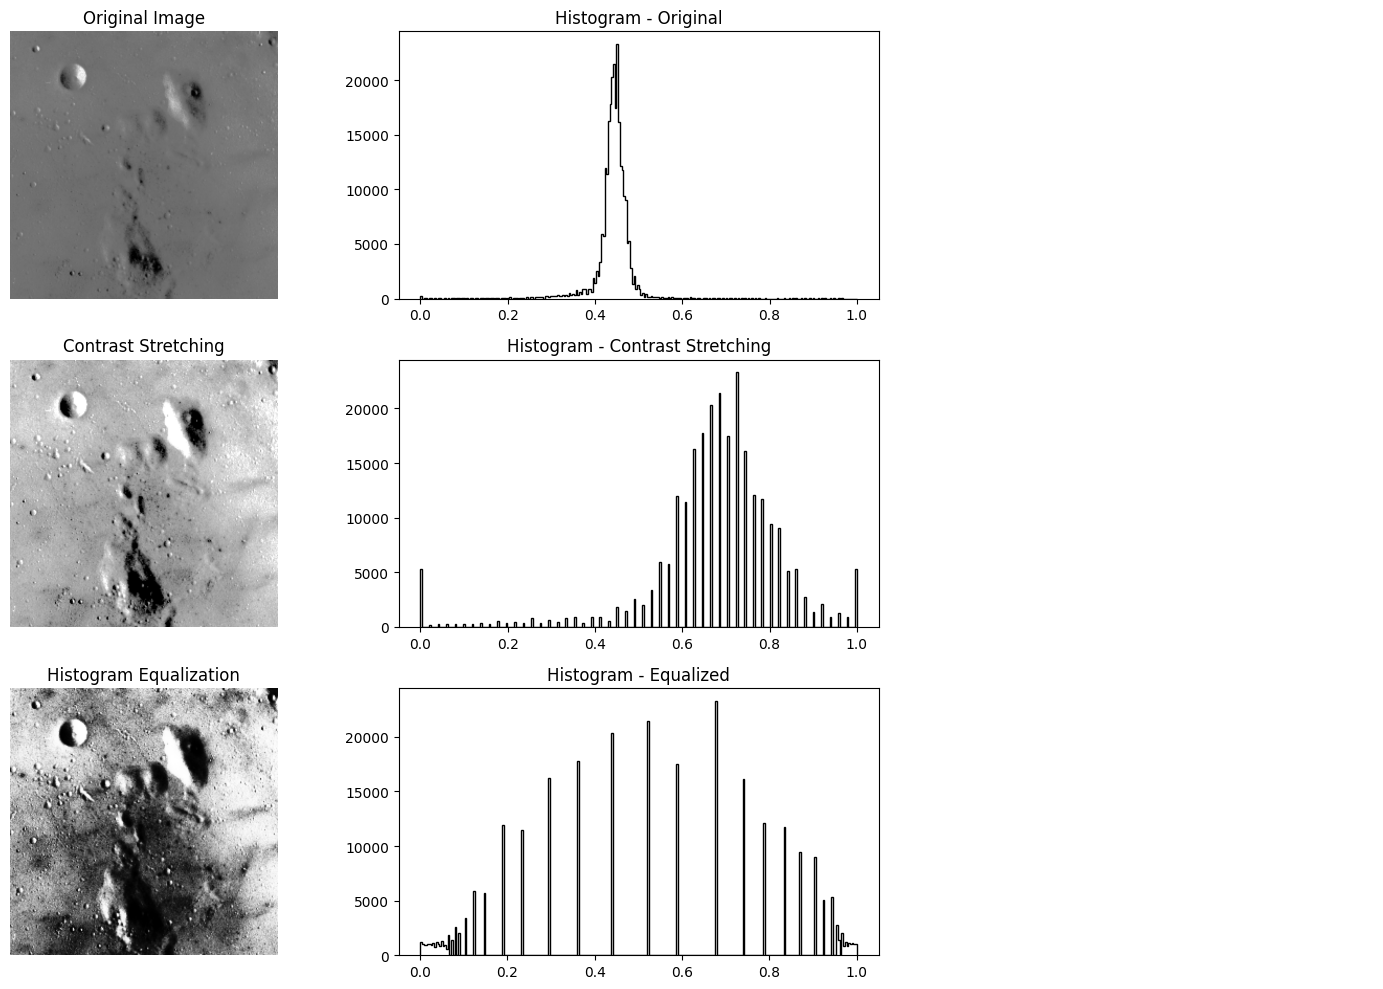

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure

# -----------------------------------------
# 1. MEMUAT CITRA KONTRAS RENDAH
# -----------------------------------------
image = img_as_float(data.moon())  # grayscale, float [0..1]

# -----------------------------------------
# 2. PEREGANGAN KONTRAS (Contrast Stretching)
# -----------------------------------------
p2, p98 = np.percentile(image, (2, 98))  # ambil nilai 2% dan 98% sebagai batas baru
contrast_stretched = exposure.rescale_intensity(image, in_range=(p2, p98))

# -----------------------------------------
# 3. EKUALISASI HISTOGRAM
# -----------------------------------------
hist_equalized = exposure.equalize_hist(image)

# -----------------------------------------
# 4. TAMPILKAN CITRA
# -----------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

# Citra Asli
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].hist(image.ravel(), bins=256, histtype='step', color='black')
axes[1].set_title("Histogram - Original")

# Contrast Stretching
axes[3].imshow(contrast_stretched, cmap='gray')
axes[3].set_title("Contrast Stretching")
axes[3].axis('off')

axes[4].hist(contrast_stretched.ravel(), bins=256, histtype='step', color='black')
axes[4].set_title("Histogram - Contrast Stretching")

# Histogram Equalization
axes[6].imshow(hist_equalized, cmap='gray')
axes[6].set_title("Histogram Equalization")
axes[6].axis('off')

axes[7].hist(hist_equalized.ravel(), bins=256, histtype='step', color='black')
axes[7].set_title("Histogram - Equalized")

# Kosongkan slot yang tidak dipakai
for i in [2, 5, 8]:
    axes[i].axis('off')

plt.tight_layout()
plt.show()


#Filter Median vs Filter Rata-rata:

<ipython-input-8-cdb9d8dd1561>:25: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  median_filtered = filters.median(noisy_image, morphology.square(3))


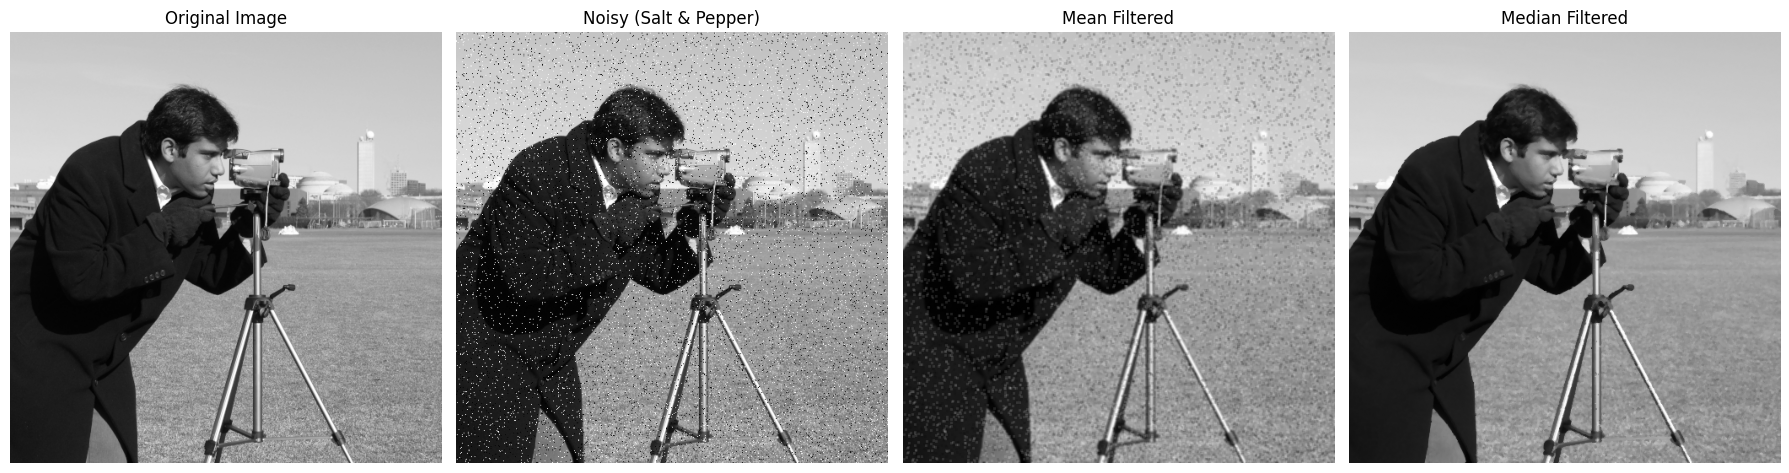

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, util, filters, morphology
from scipy import ndimage as ndi

# -----------------------------------------
# 1. Memuat citra grayscale & menambahkan noise
# -----------------------------------------
image = img_as_float(data.camera())
noisy_image = util.random_noise(image, mode='s&p', amount=0.05)

# -----------------------------------------
# 2. Filter Rata-rata (Mean Filter) - dengan konvolusi
# -----------------------------------------
kernel_size = 3
mean_kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
mean_filtered = ndi.convolve(noisy_image, mean_kernel, mode='reflect')

# Alternatif: menggunakan Gaussian filter
# mean_filtered = filters.gaussian(noisy_image, sigma=1)

# -----------------------------------------
# 3. Filter Median
# -----------------------------------------
median_filtered = filters.median(noisy_image, morphology.square(3))

# -----------------------------------------
# 4. Tampilkan Hasil
# -----------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(noisy_image, cmap='gray')
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title("Mean Filtered")
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Median Filtered")
axes[3].axis('off')

plt.tight_layout()
plt.show()
